## Baseline Model Fine-Tuning

### 1. Setup, Configuration and Device Setup

In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.models import mobilenet_v3_large
from tqdm import tqdm
import matplotlib.pyplot as plt

# Add config directory to Python path for importing project settings
project_root = Path(r"C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\waste_recycling_chatbot_pa2\config")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import dataset path and model path from configuration file
from config import PROCESSED_NEW, BASELINE_MODEL

# Set device for training (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Random Seed Setup for Reproducibility

Setting consistent random seeds ensures reproducible training results across different runs by fixing randomness in PyTorch, NumPy, and Python's random module.

In [2]:
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Seeds set with SEED={SEED}")

Seeds set with SEED=42


### 3. Data Transformations

Data transformations define how images are preprocessed before feeding them to the model. Training uses augmentation techniques to improve model generalization, while validation uses only basic preprocessing for consistent evaluation.

In [3]:
train_transform = transforms.Compose([
    # First resize slightly larger, then crop to 224x224.
    # This is closer to the standard ImageNet preprocessing and avoids too much distortion.
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),

    # Realistic augmentations for user-uploaded waste images.
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.03
    ),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),

    # Convert to tensor before RandomErasing.
    transforms.ToTensor(),

    # Mild erasing simulates partial occlusion, but should not destroy the object.
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.10)),

    # ImageNet normalization for MobileNetV3 transfer learning.
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    # Validation should be deterministic and match the inference pipeline.
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Stronger augmentation for weaker classes.
# Kept realistic: no vertical flip, because waste objects are rarely fully upside down
# in real user photos.
strong_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.25,
        hue=0.05
    ),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12)),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

### 4. Load Dataset

Dataset loading creates PyTorch datasets from the organized directory structure and wraps them in DataLoaders for efficient batch processing during training and evaluation.

In [4]:
# Load datasets from organized directory structure
DATA_PATH = PROCESSED_NEW

train_data = datasets.ImageFolder(f"{DATA_PATH}/train", transform=train_transform)
val_data = datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_transform)
test_data = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transform)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print(f"Classes: {train_data.classes}")

from torch.utils.data import Dataset

# Expanded to include all classes below ~93% accuracy in the previous run
STRONG_AUG_CLASSES = {
    'plastic', 'pet', 'residual_waste', 'rigid_plastic_container',
    'white_glass', 'metal', 'cardboard'
}

class AugmentedDataset(Dataset):
    """Applies strong_transform to weak classes, train_transform to all others."""
    def __init__(self, base_dataset, strong_classes, strong_transform, default_transform):
        self.base = base_dataset
        self.strong_indices = {
            base_dataset.class_to_idx[c]
            for c in strong_classes
            if c in base_dataset.class_to_idx
        }
        self.strong_transform = strong_transform
        self.default_transform = default_transform
        self.base.transform = None

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if label in self.strong_indices:
            img = self.strong_transform(img)
        else:
            img = self.default_transform(img)
        return img, label

train_data = AugmentedDataset(
    train_data,
    strong_classes=STRONG_AUG_CLASSES,
    strong_transform=strong_transform,
    default_transform=train_transform
)

print(f"AugmentedDataset active for: {STRONG_AUG_CLASSES}")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Total training images: {len(train_data)}")

Train: 4336 | Val: 929 | Test: 930
Classes: ['aluminium', 'brown_glass', 'cardboard', 'composite_carton', 'green_glass', 'hazardous_waste_(battery)', 'metal', 'non_waste', 'organic_waste', 'paper', 'pet', 'plastic', 'plastic_aluminium', 'residual_waste', 'rigid_plastic_container', 'white_glass', 'white_glass_metal']
AugmentedDataset active for: {'white_glass', 'plastic', 'rigid_plastic_container', 'metal', 'pet', 'residual_waste', 'cardboard'}
Total training images: 4336


### 5. Load Pretrained Model

Model initialization sets up the MobileNetV3 architecture with a custom classifier for waste classification. Pretrained weights from a baseline model are loaded for the feature extractor while the final classification layer is randomly initialized for the new task.

In [5]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
import copy

model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)

# Deeper head with two dropout stages to better regularise the gap
# between train (~96%) and val (~91%) accuracy seen in earlier runs.
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[0].in_features, 1280),
    nn.Hardswish(),
    nn.Dropout(0.5),          # increased from 0.4
    nn.Linear(1280, 512),     # added intermediate layer
    nn.Hardswish(),
    nn.Dropout(0.3),
    nn.Linear(512, 17)
)

model = model.to(device)
print("MobileNetV3 loaded with official ImageNet weights (IMAGENET1K_V2)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

MobileNetV3 loaded with official ImageNet weights (IMAGENET1K_V2)
Total parameters: 4,866,625


### 6. Early Stopping Implementation

Early stopping prevents overfitting by monitoring validation loss and stopping training when performance stops improving. It saves the best model weights and can restore them after training completes.

In [6]:
class EarlyStopping:
    """Early stopping utility to prevent overfitting during training"""
    
    def __init__(self, patience=5, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_val_loss = float('inf')
        self.counter = 0
        self.best_model_state = None
        
    def __call__(self, val_loss, model):
        print(f"[EarlyStopping] Current val_loss: {val_loss:.4f}, Best: {self.best_val_loss:.4f}")
        
        if val_loss < self.best_val_loss - self.min_delta:
            print(f"[EarlyStopping] New best! Resetting counter. Improvement: {self.best_val_loss - val_loss:.4f}")
            self.best_val_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = model.state_dict().copy()
            return False  # Continue training
        else:
            self.counter += 1
            print(f"[EarlyStopping] No improvement. Counter: {self.counter}/{self.patience}")
            return self.counter >= self.patience  # Stop training
    
    def restore_best_model(self, model):
        """Restore the best model weights found during training"""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            print("Best model weights restored!")
        else:
            print("No best model state saved!")

### 7. Training Configuration

Training configuration sets up the loss function, optimizer, and training parameters. Early stopping is initialized to monitor training progress and prevent overfitting.

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels_list = [label for _, label in train_data.base.samples]
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_list),
    y=labels_list
)
class_weights_tensor = torch.FloatTensor(class_weights_np).to(device)
print("Class weights computed:")
for cls, w in zip(train_data.base.classes, class_weights_np):
    print(f"  {cls}: {w:.3f}")

class FocalLoss(nn.Module):
    """Focal Loss down-weights easy examples so training focuses on the hard ones.
    
    Replaces plain CrossEntropyLoss. gamma=2 is the standard value from the
    original paper (Lin et al. 2017). Label smoothing is applied at the CE level
    before the focal modulation, which keeps both benefits.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(
            inputs, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0, label_smoothing=0.1)
print("Using FocalLoss (gamma=2.0, label_smoothing=0.1) with per-class weights")

PHASE1_EPOCHS = 8
PHASE2_EPOCHS = 30   # increased from 20; model was still improving at epoch 20

Class weights computed:
  aluminium: 1.119
  brown_glass: 1.119
  cardboard: 0.684
  composite_carton: 1.119
  green_glass: 1.119
  hazardous_waste_(battery): 1.119
  metal: 1.000
  non_waste: 0.911
  organic_waste: 1.045
  paper: 0.657
  pet: 1.085
  plastic: 0.898
  plastic_aluminium: 1.134
  residual_waste: 1.085
  rigid_plastic_container: 1.119
  white_glass: 1.154
  white_glass_metal: 1.119
Using FocalLoss (gamma=2.0, label_smoothing=0.1) with per-class weights


### 8. Training and Validation Functions

Training and validation functions implement the core training loop. The training function handles forward pass, loss calculation, backpropagation and parameter updates, while validation evaluates model performance without gradient updates.

In [8]:
def mixup_data(x, y, alpha=0.2):
    """Linearly interpolate two random samples and their labels."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_epoch(model, loader, criterion, optimizer, scheduler=None,
                max_grad_norm=1.0, use_mixup=True, mixup_alpha=0.2):
    """Train for one epoch with optional MixUp, gradient clipping, and LR scheduling."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    plastic_idx = train_data.base.classes.index('plastic')

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            has_plastic = (labels == plastic_idx).any()
            if not has_plastic:
                images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
                outputs = model(images)
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                _, predicted = outputs.max(1)
                # Soft accuracy weighted by the mix ratio
                correct += (lam * predicted.eq(labels_a).float()
                            + (1 - lam) * predicted.eq(labels_b).float()).sum().item()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item()
        total += labels.size(0)

    if scheduler is not None:
        scheduler.step()

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    """Evaluate model performance without gradient updates."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

### 9. Training Loop with Early Stopping

The main training loop executes the training process for multiple epochs, tracking performance metrics and implementing early stopping to prevent overfitting. Training history is recorded for later analysis and visualization.

In [9]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
sep = "=" * 60

# ── PHASE 1: Frozen backbone ─────────────────────────────────────
print(sep)
print("PHASE 1: Training classifier head only (backbone frozen)")
print(sep)

for param in model.features.parameters():
    param.requires_grad = False

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_p1:,}")

optimizer1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-3
)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=PHASE1_EPOCHS, eta_min=1e-6)
es1 = EarlyStopping(patience=5, min_delta=0.005, restore_best_weights=True)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer1,
                                        scheduler=None, use_mixup=True, mixup_alpha=0.2)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler1.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(f"[P1] Epoch {epoch}/{PHASE1_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    if es1(val_loss, model):
        print(f"Phase 1 early stopping at epoch {epoch}")
        break

es1.restore_best_model(model)
print("Phase 1 complete.")

# ── PHASE 2: Unfrozen backbone, fine-tune everything ─────────────
print(sep)
print("PHASE 2: Fine-tuning full model (backbone unfrozen)")
print(sep)

for param in model.features.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_p2:,}")

# Backbone gets stronger weight decay (2e-3) to reduce overfitting in the
# fine-tuning phase; classifier head uses a lighter 1e-3 since it still needs
# to move more freely toward the target distribution.
optimizer2 = torch.optim.Adam([
    {"params": model.features.parameters(),    "lr": 1e-5, "weight_decay": 2e-3},
    {"params": model.classifier.parameters(),  "lr": 1e-4, "weight_decay": 1e-3}
])
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS, eta_min=1e-6)
es2 = EarlyStopping(patience=7, min_delta=0.005, restore_best_weights=True)

for epoch in range(1, PHASE2_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer2,
                                        scheduler=None, use_mixup=True, mixup_alpha=0.3)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler2.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(f"[P2] Epoch {epoch}/{PHASE2_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    if es2(val_loss, model):
        print(f"Phase 2 early stopping at epoch {epoch}")
        break

es2.restore_best_model(model)
total_epochs = len(history["val_loss"])
print(f"Training complete. Total epochs: {total_epochs}")

PHASE 1: Training classifier head only (backbone frozen)
Trainable parameters: 1,894,673


Validation: 100%|██████████| 30/30 [00:08<00:00,  3.54it/s]


[P1] Epoch 1/8 | Train Loss: 1.2624 | Train Acc: 57.03% | Val Loss: 0.7765 | Val Acc: 72.98%
[EarlyStopping] Current val_loss: 0.7765, Best: inf
[EarlyStopping] New best! Resetting counter. Improvement: inf


Validation: 100%|██████████| 30/30 [00:08<00:00,  3.42it/s]


[P1] Epoch 2/8 | Train Loss: 0.8087 | Train Acc: 73.24% | Val Loss: 0.6530 | Val Acc: 79.44%
[EarlyStopping] Current val_loss: 0.6530, Best: 0.7765
[EarlyStopping] New best! Resetting counter. Improvement: 0.1234


...

[P2] Epoch 28/30 | Train Loss: 0.3569 | Train Acc: 93.42% | Val Loss: 0.3594 | Val Acc: 91.28%
[EarlyStopping] Current val_loss: 0.3594, Best: 0.3597
[EarlyStopping] No improvement. Counter: 2/7


Validation: 100%|██████████| 30/30 [00:08<00:00,  3.61it/s]


[P2] Epoch 29/30 | Train Loss: 0.3441 | Train Acc: 93.57% | Val Loss: 0.3591 | Val Acc: 91.28%
[EarlyStopping] Current val_loss: 0.3591, Best: 0.3597
[EarlyStopping] No improvement. Counter: 3/7


Validation: 100%|██████████| 30/30 [00:09<00:00,  3.30it/s]

[P2] Epoch 30/30 | Train Loss: 0.3733 | Train Acc: 92.20% | Val Loss: 0.3587 | Val Acc: 91.17%
[EarlyStopping] Current val_loss: 0.3587, Best: 0.3597
[EarlyStopping] No improvement. Counter: 4/7
Best model weights restored!
Training complete. Total epochs: 38


### 10. Model Saving

Model saving preserves the trained model weights, optimizer state, and training history for future use or deployment. This checkpoint includes all necessary information to resume training or perform inference.

In [ ]:
from pathlib import Path

# Notebook lives in waste_recycling_chatbot_pa2/notebooks/
# -> one level up to package root, then models/baseline/
MODEL_DIR = (
    Path.cwd().parent / "models" / "baseline"
    if Path.cwd().name == "notebooks"
    else Path.cwd() / "models" / "baseline"
)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_DIR / "finetuned_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer2.state_dict(),
    'history': history
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH}")

### 11. Training History Visualization

Visualizing training and validation metrics throughout epochs helps identify model convergence behavior, overfitting, and confirms that early stopping worked correctly.

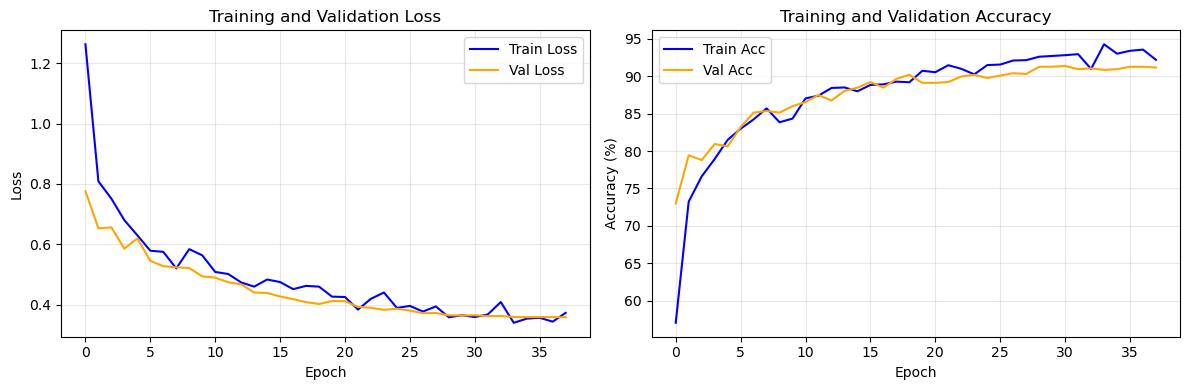

Training history plot saved to C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\waste_recycling_chatbot_pa2\outputs\figures\training_history.png


In [11]:
# Import config for organized file saving
from config import FIGURES_DIR

# Create figures directory if it doesn't exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create subplot layout for training metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot training and validation loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Training and Validation Loss')
ax1.grid(True, alpha=0.3)

# Plot training and validation accuracy
ax2.plot(history['train_acc'], label='Train Acc', color='blue')
ax2.plot(history['val_acc'], label='Val Acc', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.set_title('Training and Validation Accuracy')
ax2.grid(True, alpha=0.3)

# Save to organized output directory
plt.tight_layout()
figure_path = FIGURES_DIR / 'training_history.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Training history plot saved to {figure_path}")

### 12. Final Model Evaluation

Final evaluation tests the optimized model on unseen test data to measure real-world performance and confirm that improvements achieved during training generalize to new samples.

In [12]:
test_loss, test_acc = validate(model, test_loader, criterion)
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Validation: 100%|██████████| 30/30 [00:09<00:00,  3.30it/s]


Test Loss: 0.3379 | Test Acc: 93.23%


### 12b. Test-Time Augmentation (TTA) Evaluation

TTA averages softmax predictions over 5 views of each image (original + horizontal flip + 3 centre-crop zoom levels). This costs 5× inference time but typically gains 1–2% accuracy on ambiguous classes like `plastic` and `white_glass` without any retraining.

In [13]:
def predict_with_tta(model, loader, n_augments=5):
    """Average softmax predictions over original + flipped + zoomed-in views.

    All augmentations are applied to already-normalised tensors so no dataset
    access is needed and the function works with any loader.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"TTA ({n_augments} passes)"):
            images = images.to(device)
            h, w = images.shape[2], images.shape[3]
            batch_probs = torch.zeros(images.size(0), 17).to(device)

            # Pass 1 — original centre-crop
            batch_probs += torch.softmax(model(images), dim=1)
            # Pass 2 — horizontal flip
            batch_probs += torch.softmax(model(torch.flip(images, dims=[3])), dim=1)
            # Passes 3–5 — slight zoom in (crop border pixels, resize back)
            for margin in [4, 8, 12]:
                cropped = images[:, :, margin:h - margin, margin:w - margin]
                zoomed = torch.nn.functional.interpolate(
                    cropped, size=(h, w), mode='bilinear', align_corners=False
                )
                batch_probs += torch.softmax(model(zoomed), dim=1)

            batch_probs /= n_augments
            _, predicted = batch_probs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

tta_preds, tta_labels = predict_with_tta(model, test_loader, n_augments=5)
tta_acc = 100. * (tta_preds == tta_labels).sum() / len(tta_labels)

print(f"\nStandard Test Accuracy : {test_acc:.2f}%")
print(f"TTA     Test Accuracy  : {tta_acc:.2f}%")
print(f"TTA gain               : +{tta_acc - test_acc:.2f}%")

# Per-class TTA breakdown
tta_cm = confusion_matrix(tta_labels, tta_preds) if 'confusion_matrix' in dir() else None
try:
    from sklearn.metrics import confusion_matrix as _cm
    tta_cm = _cm(tta_labels, tta_preds)
    actual_classes_tta = train_data.base.classes
    tta_per_class = 100. * tta_cm.diagonal() / tta_cm.sum(axis=1)
    print("\nPer-class TTA accuracy:")
    for cls, acc in zip(actual_classes_tta, tta_per_class):
        print(f"  {cls:<25} {acc:.2f}%")
except Exception as e:
    print(f"Per-class breakdown skipped: {e}")

TTA (5 passes): 100%|██████████| 30/30 [00:36<00:00,  1.21s/it]


Standard Test Accuracy : 93.23%
TTA     Test Accuracy  : 93.23%
TTA gain               : +0.00%

Per-class TTA accuracy:
  aluminium                 100.00%
  brown_glass               93.88%
  cardboard                 92.50%
  composite_carton          100.00%
  green_glass               97.96%
  hazardous_waste_(battery) 100.00%
  metal                     89.09%
  non_waste                 91.67%
  organic_waste             100.00%
  paper                     96.43%
  pet                       88.00%
  plastic                   77.05%
  plastic_aluminium         97.92%
  residual_waste            94.00%
  rigid_plastic_container   91.84%
  white_glass               80.85%
  white_glass_metal         95.92%


### 13. Detailed Evaluation with Confusion Matrix

Detailed analysis collects model predictions on the test set and prepares data for comprehensive evaluation metrics including confusion matrix and classification report to understand per-class performance.

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect all predictions and labels
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting predictions"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions on test set
test_preds, test_labels = get_predictions(model, test_loader)

### 14. Confusion Matrix Visualization

The confusion matrix provides detailed insights into model performance for each waste category, showing which classes are correctly classified and where misclassifications occur most frequently.

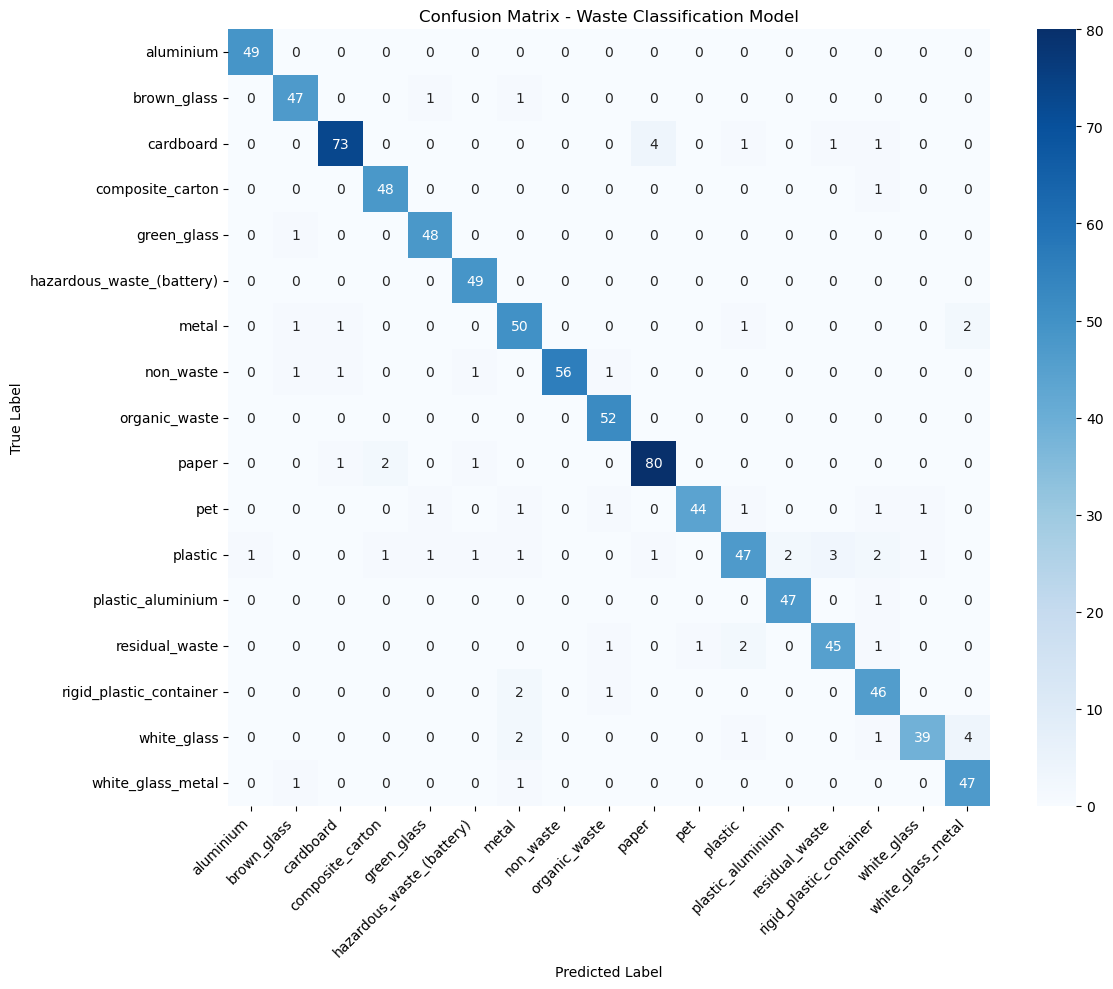

Confusion matrix saved to C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\waste_recycling_chatbot_pa2\outputs\figures\confusion_matrix.png


In [15]:
# Generate confusion matrix from test predictions
cm = confusion_matrix(test_labels, test_preds)
actual_classes = train_data.base.classes

# Create confusion matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actual_classes, 
            yticklabels=actual_classes)
plt.title('Confusion Matrix - Waste Classification Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save to config-defined figures directory
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to {FIGURES_DIR / 'confusion_matrix.png'}")

### 15. Per-Class Accuracy

Per-class analysis breaks down model performance for each waste category, revealing which materials are classified most accurately and identifying potential areas for improvement.

In [16]:
print("\nPer-Class Performance:")
print("=" * 60)

# Calculate accuracy for each waste category
class_correct = cm.diagonal()
class_total = cm.sum(axis=1)
class_accuracy = 100. * class_correct / class_total

# Get actual classes from test set
actual_classes = [train_data.base.classes[i] for i in np.unique(test_labels)]

# Display detailed per-class results
for i, class_name in enumerate(actual_classes):
    print(f"{class_name:<25} Accuracy: {class_accuracy[i]:>6.2f}% ({class_correct[i]}/{class_total[i]})")

print("=" * 60)
print(f"Overall Test Accuracy: {100. * class_correct.sum() / class_total.sum():.2f}%")

# Find all classes with perfect performance
perfect_classes = [actual_classes[i] for i, acc in enumerate(class_accuracy) if acc == 100.0]
worst_class_idx = np.argmin(class_accuracy)

print(f"\nPerfect performing classes (100%): {', '.join(perfect_classes)}")
print(f"Worst performing class: {actual_classes[worst_class_idx]} ({class_accuracy[worst_class_idx]:.2f}%)")


Per-Class Performance:
aluminium                 Accuracy: 100.00% (49/49)
brown_glass               Accuracy:  95.92% (47/49)
cardboard                 Accuracy:  91.25% (73/80)
composite_carton          Accuracy:  97.96% (48/49)
green_glass               Accuracy:  97.96% (48/49)
hazardous_waste_(battery) Accuracy: 100.00% (49/49)
metal                     Accuracy:  90.91% (50/55)
non_waste                 Accuracy:  93.33% (56/60)
organic_waste             Accuracy: 100.00% (52/52)
paper                     Accuracy:  95.24% (80/84)
pet                       Accuracy:  88.00% (44/50)
plastic                   Accuracy:  77.05% (47/61)
plastic_aluminium         Accuracy:  97.92% (47/48)
residual_waste            Accuracy:  90.00% (45/50)
rigid_plastic_container   Accuracy:  93.88% (46/49)
white_glass               Accuracy:  82.98% (39/47)
white_glass_metal         Accuracy:  95.92% (47/49)
Overall Test Accuracy: 93.23%

Perfect performing classes (100%): aluminium, hazardous_waste

### 16. Classification Report

The classification report provides comprehensive per-class metrics including precision, recall, and F1-score, offering deeper insights into model performance beyond simple accuracy measurements.

In [17]:
print("\nDetailed Classification Report:")
print("=" * 80)
print(classification_report(test_labels, test_preds, 
                          target_names=actual_classes,  # Use actual_classes from previous analysis
                          digits=3))


Detailed Classification Report:
                           precision    recall  f1-score   support

                aluminium      0.980     1.000     0.990        49
              brown_glass      0.922     0.959     0.940        49
                cardboard      0.961     0.912     0.936        80
         composite_carton      0.941     0.980     0.960        49
              green_glass      0.941     0.980     0.960        49
hazardous_waste_(battery)      0.942     1.000     0.970        49
                    metal      0.862     0.909     0.885        55
                non_waste      1.000     0.933     0.966        60
            organic_waste      0.929     1.000     0.963        52
                    paper      0.941     0.952     0.947        84
                      pet      0.978     0.880     0.926        50
                  plastic      0.887     0.770     0.825        61
        plastic_aluminium      0.959     0.979     0.969        48
           residual_waste   

### 17. Automated Misclassification Detection and Organization

This code systematically organizes misclassified images by copying them into a dedicated directory with descriptive filenames that clearly indicate both the true label and predicted label, facilitating targeted analysis of model errors and supporting iterative model improvement efforts.

In [18]:
import shutil
from pathlib import Path

misclassified_dir = FIGURES_DIR / 'misclassified'
misclassified_dir.mkdir(parents=True, exist_ok=True)

misclassified_count = 0

for idx, (true_idx, pred_idx) in enumerate(zip(test_labels, test_preds)):
    if true_idx != pred_idx:
        true_label = actual_classes[true_idx]
        pred_label = actual_classes[pred_idx]
        
        img_path = Path(test_data.samples[idx][0])
        new_filename = f"{true_label}_predicted_as_{pred_label}_{img_path.name}"
        
        shutil.copy(img_path, misclassified_dir / new_filename)
        misclassified_count += 1

print(f"\nCopied {misclassified_count} misclassified images to {misclassified_dir}")
print("Images are named as 'true_label_predicted_as_pred_label_original_name'.")



Copied 63 misclassified images to C:\Users\Lejlum\Documents\PA2_Recycling_Chatbot\waste_recycling_chatbot_pa2\outputs\figures\misclassified
Images are named as 'true_label_predicted_as_pred_label_original_name'.


### 18. Comprehensive Misclassification Logging and Documentation

Lastely, this code creates a detailed CSV log of all misclassified images by collecting metadata including file paths, indices, true labels, and predicted labels into a structured DataFrame, enabling systematic tracking and analysis of classification errors for comprehensive model evaluation and debugging.

In [19]:
import pandas as pd

records = []

for idx, (true_idx, pred_idx) in enumerate(zip(test_labels, test_preds)):
    if true_idx != pred_idx:
        true_label = actual_classes[true_idx]
        pred_label = actual_classes[pred_idx]
        img_path = Path(test_data.samples[idx][0])

        records.append({
            "idx": idx,
            "file": img_path.name,
            "path": str(img_path),
            "true_label": true_label,
            "pred_label": pred_label
        })

df_mis = pd.DataFrame(records)
df_mis.to_csv(FIGURES_DIR / "misclassified_log.csv", index=False)
df_mis.head()

,idx,file,path,true_label,pred_label
0,57,0958.jpg,C:\Users\Lejlum\Documents\PA2_Recycling_Chatbo...,brown_glass,metal
1,97,6976.jpg,C:\Users\Lejlum\Documents\PA2_Recycling_Chatbo...,brown_glass,green_glass
2,99,0029.jpg,C:\Users\Lejlum\Documents\PA2_Recycling_Chatbo...,cardboard,residual_waste
3,112,0311.jpg,C:\Users\Lejlum\Documents\PA2_Recycling_Chatbo...,cardboard,paper
4,140,0519.jpg,C:\Users\Lejlum\Documents\PA2_Recycling_Chatbo...,cardboard,plastic
